In [2]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [3]:
# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv("heart.csv")
print(df.shape)
print(df.head())



(253680, 22)
   HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                   0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                   0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                   0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                   0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   Diabetes  PhysActivity  Fruits  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0       0.0           0.0     0.0  ...            1.0          0.0      5.0   
1       0.0           1.0     0.0  ...            0.0          1.0      3.0   
2       0.0           0.0     1.0  ...            1.0          1.0      5.0   
3       0.0           1.0     1.0  ...            1.0          0.0      2.0   
4       0.0           1.0     1.0  ...            1.0          0.0      2.0   

   MentHlth  PhysHlth  DiffWalk  Sex   Age 

In [4]:
# ==========================
# CLEANING
# ==========================
print(df.isnull().sum())

df = df.drop_duplicates()
print("After removing duplicates:", df.shape)


# ==========================
# TARGET SPLIT
# ==========================
target = "HeartDiseaseorAttack"   # غيّرها لو اسم العمود مختلف

X = df.drop(target, axis=1)
y = df[target]


HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64
After removing duplicates: (229781, 22)


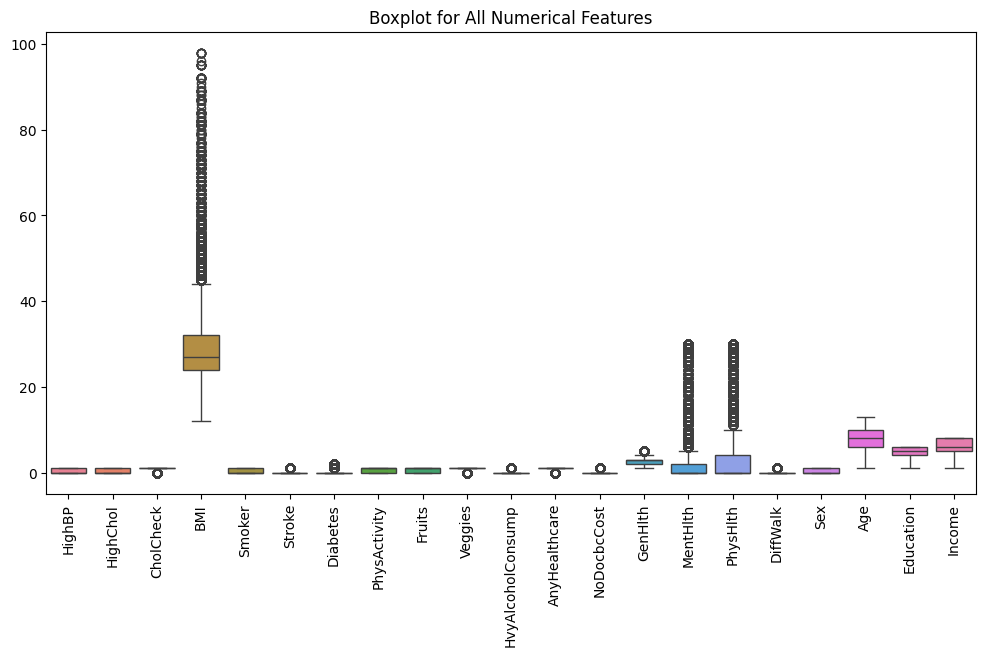

In [5]:

# ==========================
# BOX PLOT (ALL DATA IN ONE PLOT)
# ==========================

num_cols = X.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=X[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for All Numerical Features")
plt.show()


In [ ]:

# ==========================
# DETECT OUTLIERS (CHECK FIRST)
# ==========================

def detect_outliers_iqr(data, cols):
    """Detect outliers using IQR method"""
    outliers_count = 0
    outlier_cols = []
    
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        col_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        if col_outliers > 0:
            outliers_count += col_outliers
            outlier_cols.append((col, col_outliers))
    
    return outliers_count, outlier_cols

# Check for outliers
outliers_count, outlier_cols = detect_outliers_iqr(X, num_cols)

print(f"Total outliers found: {outliers_count}")
if outlier_cols:
    print("\nOutliers per column:")
    for col, count in outlier_cols:
        print(f"  {col}: {count} outliers")
else:
    print("No outliers detected!")

# ==========================
# IQR function - Apply ONLY if outliers exist
# ==========================

if outliers_count > 0:
    print("\n✓ Applying outlier removal method...")
    
    def remove_outliers_iqr(data, cols):
        for col in cols:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            data[col] = np.clip(data[col], lower, upper)

        return data

    # Apply outlier removal
    X = remove_outliers_iqr(X, num_cols)
    print(f"After removing outliers: {X.shape}")
else:
    print("\n✗ No outliers to remove - keeping data as is")


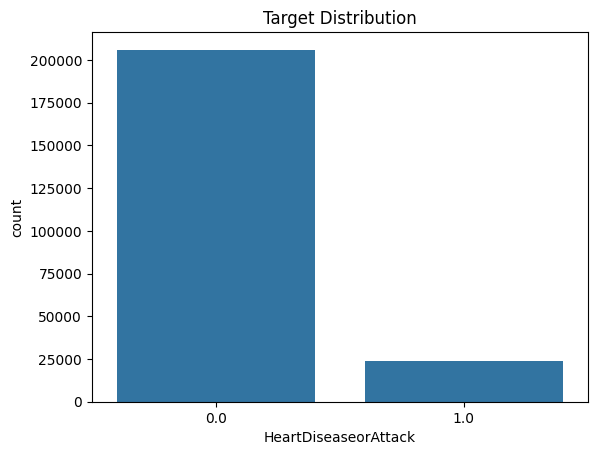

After balancing:
HeartDiseaseorAttack
0.0    23717
1.0    23717
Name: count, dtype: int64


In [7]:
# ==========================
# EDA
# ==========================
plt.figure()
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()


# ==========================
# BALANCING (OVER + UNDER SAMPLING)
# ==========================

df_balanced = pd.concat([X, y], axis=1)

class_0 = df_balanced[df_balanced[target] == 0]
class_1 = df_balanced[df_balanced[target] == 1]

# Under-sample majority (0)
class_0_under = class_0.sample(len(class_1), random_state=42)

# Over-sample minority (1)
class_1_over = class_1.sample(len(class_0_under), replace=True, random_state=42)

# Combine both
df_balanced = pd.concat([class_0_under, class_1_over])

# Shuffle data
df_balanced = df_balanced.sample(frac=1, random_state=42)

# Split again
X = df_balanced.drop(target, axis=1)
y = df_balanced[target]

print("After balancing:")
print(y.value_counts())


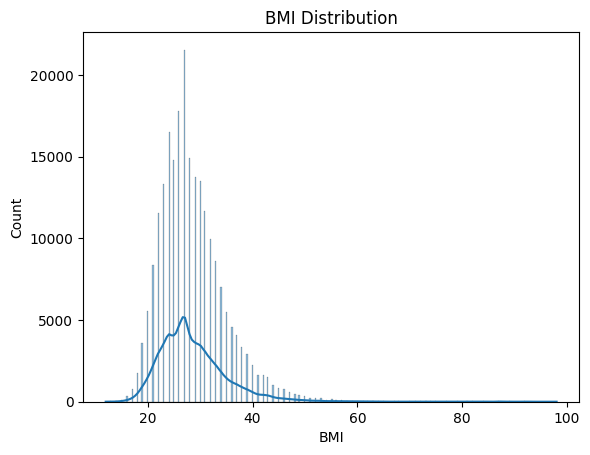

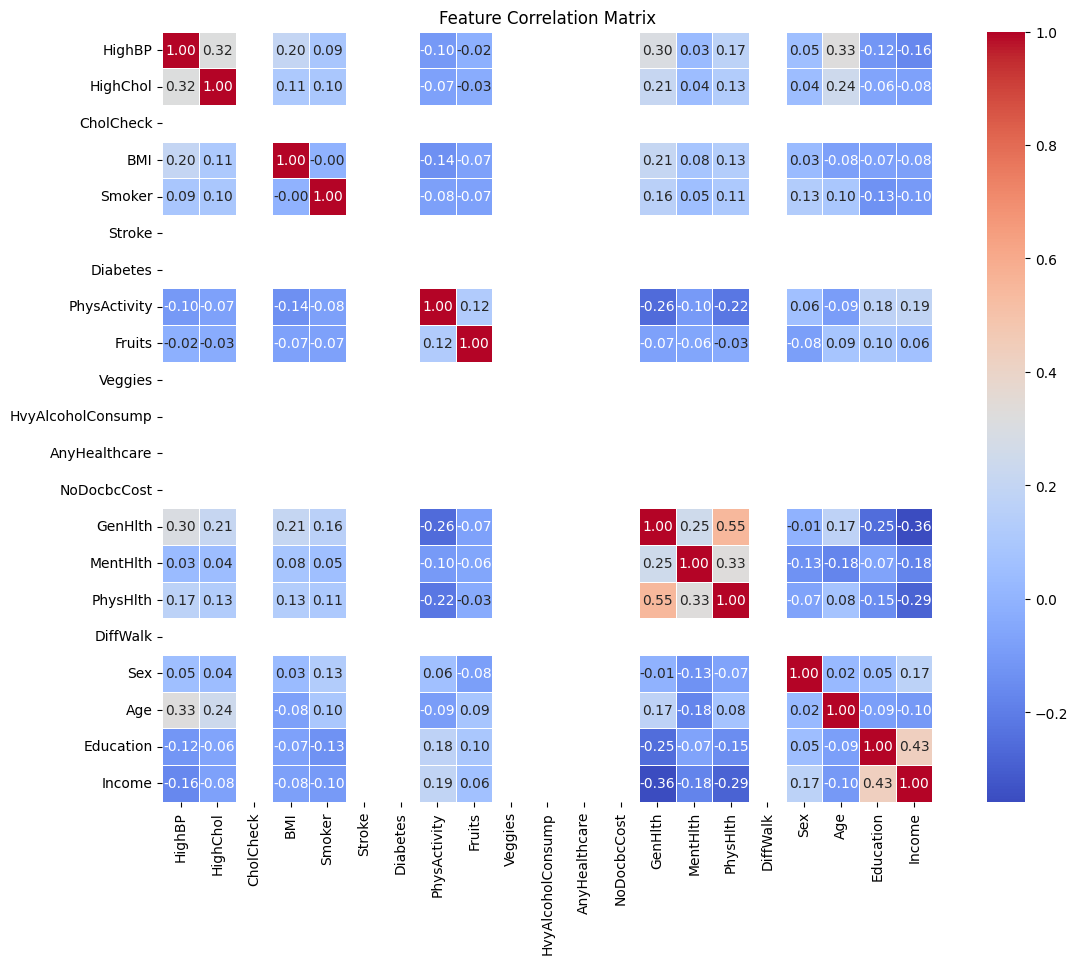

In [8]:

plt.figure()
sns.histplot(df["BMI"], kde=True)
plt.title("BMI Distribution")
plt.show()


# ==========================
# CORRELATION MATRIX (IMPROVED)
# ==========================

plt.figure(figsize=(14, 10))

corr = X.corr()

sns.heatmap(
    corr,
    annot=True,        # 👈 يطلع الأرقام
    fmt=".2f",         # 👈 رقمين بعد الكومه
    cmap="coolwarm",   # الألوان
    linewidths=0.5,    # فواصل بين الخلايا
    square=True        # شكل مرتب
)

plt.title("Feature Correlation Matrix")
plt.show()


In [9]:
# ==========================
# TRAIN TEST SPLIT (NO LEAKAGE)
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==========================
# PIPELINE (Scaling + PCA + SVM)
# ==========================
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("svm", SVC())
])


In [10]:
# ==========================
# HYPERPARAMETER TUNING
# ==========================
params = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01],
    "svm__kernel": ["rbf"]
}

grid = GridSearchCV(pipeline, params, cv=3, verbose=2, n_jobs=-1)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


# ==========================
# FINAL MODEL
# ==========================
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}



Accuracy: 0.7532412775376831

Classification Report:

              precision    recall  f1-score   support

         0.0       0.79      0.69      0.74      4744
         1.0       0.72      0.82      0.77      4743

    accuracy                           0.75      9487
   macro avg       0.76      0.75      0.75      9487
weighted avg       0.76      0.75      0.75      9487



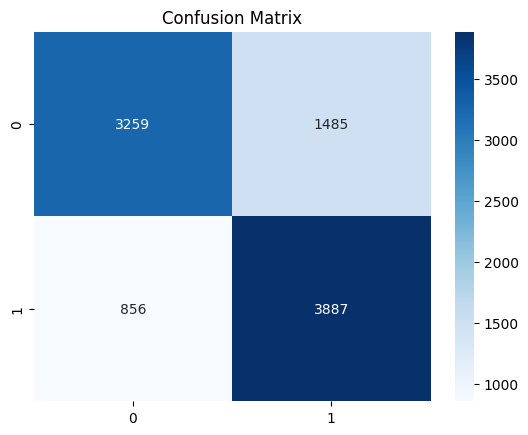

['svm_model.pkl']

In [ ]:
# ==========================
# EVALUATION
# ==========================
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# ==========================
# CONFUSION MATRIX
# ==========================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# ==========================
# SAVE MODEL (BONUS FOR DEPLOYMENT)
# ==========================
import joblib
import pickle

# Save model
joblib.dump(best_model, "svm_model.pkl")

# Also save feature names and column info
model_metadata = {
    'feature_names': list(X_train.columns),
    'n_features': X_train.shape[1],
    'model': best_model
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print(f"\n✓ Model saved with {X_train.shape[1]} features")
print(f"Features: {list(X_train.columns)}")
